In [1]:
import os
import re
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

from pathlib import Path

/Users/yavuzlule/Desktop/bsc-thesis-copy/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_embeddings(df, sentence_embedding_model):
    """
    df: pandas DataFrame with 'text' column
    sentence_embedding_model: instance of SentenceTransformer
    Returns: numpy array of embeddings
    """
    texts = df['text'].tolist()
    embeddings = sentence_embedding_model.encode(texts, show_progress_bar=True)
    return embeddings


def train_model(model, dataset):
    """
    model: sklearn model (LogisticRegression, SVM with probability, XGBoost, etc.)
    dataset: pandas DataFrame with 'text' and 'label'
    Returns trained model
    """
    X = dataset['mini_lm_embeddings'].tolist()  # embeddings must be precomputed and added to df
    y = dataset['is_cooking'].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    print(f"Model training completed. Test accuracy: {model.score(X_test, y_test):.4f}")
    return model



def build_df_from_txt(directory_path, is_cooking, category):
    rows = []
    directory = Path(directory_path)

    for file_path in directory.glob("*.txt"):
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        rows.append({
            "title": file_path.stem,
            "text": text,
            "is_cooking": is_cooking,
            "category": category
        })
 
    return pd.DataFrame(rows)


def preprocess_text(text):
    if text is None:
        return ""

    # lowercase
    text = text.lower()

    # normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # remove multiple empty lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)

    # collapse repeated spaces/tabs
    text = re.sub(r"[ \t]+", " ", text)

    # remove strange OCR artifacts (common in scanned books)
    text = re.sub(r"[^\w\s\n.,:;!?()\-/]", "", text)

    return text.strip()

def save_model(model, dir_name, model_name):
    """
    Saves a trained model to disk with a custom name.
    """
    os.makedirs(dir_name, exist_ok=True)
    model_path = os.path.join(dir_name, f"{model_name}.joblib")
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")
    

def divide_books_on_chars(df, subdivision_size):
    rows = []

    for row in df.itertuples(index=False):
        title = row.title
        text = row.text

        for i in range(0, len(text), subdivision_size):
            chunk = text[i:i + subdivision_size]
            index_of_subtext = i // subdivision_size + 1

            rows.append({
                "title": title,
                "index_of_subtext": index_of_subtext,
                "text": chunk
            })

    return pd.DataFrame(rows)

In [3]:
df_cookbook = build_df_from_txt("data/archive-americana-cookbook-download-desc", 1, 'cookbook')
df_other = build_df_from_txt("data/archive-americana-fiction-literature-technology-download-desc", 0, 'other')
#df_cookery_cookbook = build_df_from_txt("data/archive-americana-download-desc", 1, 'cookbook')

In [4]:
df_cookbook.head()

,title,text,is_cooking,category
0,bostoncookingsch19hill_8_djvu,y. \n\n\n7^ \n\n\n1 \n\n\nl^ \n\n\nj Va.' \n\...,1,cookbook
1,bostoncookingsch19hill_9_djvu,"j(»£ook).ia) \n\n\n^ \n\n\n// , \n\n\n\NrU \n\...",1,cookbook
2,cookerybookforfa00ppo_djvu,fW^ \n\n\n^^^^•^^ff'll Mil I 111 nil \n\...,1,cookbook
3,montgomerywardco00cook_djvu,"%s^ \n\n\n0 o. \n\n\n-p \n\n\nr.i"" . ...",1,cookbook
4,leguideculinaire00esco_0_djvu,rs \nqe \n\n\nAtees \n\n\n% * L +: d fi LOTO \...,1,cookbook


In [3]:
gutenberg = pd.read_parquet("saved_data/dataset.parquet")

In [6]:
#df_cooking_combined = pd.concat([df_cookbook, df_cookery_cookbook], ignore_index=True)
df_cooking_combined = df_cookbook.drop_duplicates(subset=["title"])

df_cooking_combined.describe()


,is_cooking
count,505.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [14]:
df_cooking_combined.head()

,title,text,is_cooking,category
0,bostoncookingsch19hill_8_djvu,y. \n\n\n7^ \n\n\n1 \n\n\nl^ \n\n\nj Va.' \n\...,1,cookbook
1,bostoncookingsch19hill_9_djvu,"j(»£ook).ia) \n\n\n^ \n\n\n// , \n\n\n\NrU \n\...",1,cookbook
2,cookerybookforfa00ppo_djvu,fW^ \n\n\n^^^^•^^ff'll Mil I 111 nil \n\...,1,cookbook
3,montgomerywardco00cook_djvu,"%s^ \n\n\n0 o. \n\n\n-p \n\n\nr.i"" . ...",1,cookbook
4,leguideculinaire00esco_0_djvu,rs \nqe \n\n\nAtees \n\n\n% * L +: d fi LOTO \...,1,cookbook


In [ ]:
gutenberg.tail()

,id,text
61335,16181-8,"Project Gutenberg's Young Lion of the Woods, b..."
61336,52151-0,"﻿The Project Gutenberg eBook, Inspiration, by ..."
61337,12256-8,The Project Gutenberg EBook of Mistress Penwic...
61338,12256-8,The Project Gutenberg EBook of Mistress Penwic...
61339,55726-0,﻿The Project Gutenberg EBook of The Blue Duche...


In [19]:
gutenberg = gutenberg.iloc[:10000]

In [20]:
gutenberg.tail()

,id,text
995,41359-8,The Project Gutenberg EBook of The Golden Boug...
996,63450-0,﻿The Project Gutenberg EBook of Course of Stud...
997,53226-0,"﻿The Project Gutenberg EBook of Oscar Wilde, a..."
998,15563-8,The Project Gutenberg EBook of Reason and Fait...
999,15563-8,The Project Gutenberg EBook of Reason and Fait...


In [24]:
cooking_df = df_cooking_combined[['title', 'text']]
not_cooking_df = gutenberg[['id', 'text']].iloc[:1000].rename(columns={'id': 'title'})

df = pd.concat([cooking_df, not_cooking_df], ignore_index=True)
df = pd.concat([df, df_other], ignore_index=True)

In [27]:
df['is_cooking'] = [1]*len(cooking_df) + [0]*(len(not_cooking_df) + len(df_other))
df['category'] = ['cookbook']*len(cooking_df) + ['gutenberg']*len(not_cooking_df) + ['other']*len(df_other)

In [30]:
df.tail()

,title,text,is_cooking,category
2517,arabianpoetryfo00clougoog_djvu,Google \n\n\nThis is a digital copy of a...,0,other
2518,romanischebibli00verlgoog_djvu,Google \n\n\nThis is a digital copy of a...,0,other
2519,readershandbook00brewgoog_djvu,\n\n\nGoogle \n\n\nThis is a digital copy of a...,0,other
2520,catalogusvandeb04biblgoog_djvu,Google \n\n\nThis is a digital copy of a...,0,other
2521,sim_national-union-catalog_1948-1952_9_djvu,"LIBRARY \nUNIVERSITY MICROFILMS, INC. \n\n\nTh...",0,other


In [35]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

df["text"] = df["text"].apply(preprocess_text)

embeddings = get_embeddings(df, embedding_model)

df['mini_lm_embeddings'] = list(embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1756.96it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 79/79 [15:28<00:00, 11.76s/it]  


In [ ]:
svm_model = SVC(probability=True)
logreg_model = LogisticRegression(solver='liblinear')
xgbmodel = XGBClassifier()


In [37]:

X = np.vstack(df['mini_lm_embeddings'].values) 
y = df['is_cooking'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', max_iter=1000, class_weight='balanced'),
    'SVM': SVC(probability=True, kernel='linear', class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

from sklearn.metrics import classification_report

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)

    print(f"\n{name}")
    print(f"AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression
AUC: 0.9822
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       329
           1       0.94      0.88      0.91       176

    accuracy                           0.94       505
   macro avg       0.94      0.93      0.93       505
weighted avg       0.94      0.94      0.94       505


SVM
AUC: 0.9810
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       329
           1       0.93      0.88      0.90       176

    accuracy                           0.93       505
   macro avg       0.93      0.92      0.93       505
weighted avg       0.93      0.93      0.93       505



/Users/yavuzlule/Desktop/bsc-thesis-copy/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [08:21:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
AUC: 0.9831
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       329
           1       0.96      0.89      0.92       176

    accuracy                           0.95       505
   macro avg       0.95      0.94      0.94       505
weighted avg       0.95      0.95      0.95       505



/Users/yavuzlule/Desktop/bsc-thesis-copy/.venv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [09:26:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


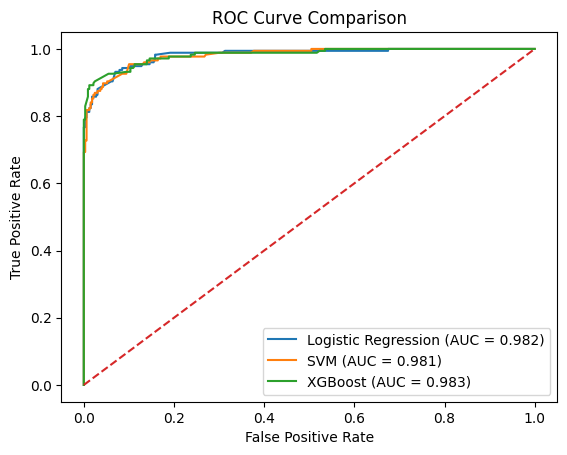

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure()

for name, model in models.items():
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()

In [39]:
for name, model in models.items():
    name = name.strip() + "_v2"
    save_model(model, "saved_models", name)

Model saved to saved_models/Logistic Regression_v2.joblib
Model saved to saved_models/SVM_v2.joblib
Model saved to saved_models/XGBoost_v2.joblib


In [53]:
subdivsize = 30000

In [54]:
df = divide_books_on_chars(df, subdivision_size=subdivsize)

In [55]:
trained_logreg = joblib.load("saved_models/logreg_v2.joblib")
trained_svm = joblib.load("saved_models/SVM_v2.joblib")
trained_xgb = joblib.load("saved_models/XGBoost_v2.joblib")

In [56]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = get_embeddings(df, embedding_model)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 868.04it/s, Materializing param=pooler.dense.weight]                              
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 8791/8791 [51:23<00:00,  2.85it/s]


In [57]:
df['mini_lm_embeddings'] = list(embeddings)

In [58]:
X = np.vstack(df["mini_lm_embeddings"].values)

df["is_cooking_proba_logreg"] = trained_logreg.predict_proba(X)[:, 1]
df["is_cooking_proba_svm"] = trained_svm.predict_proba(X)[:, 1]
df["is_cooking_proba_xgb"] = trained_xgb.predict_proba(X)[:, 1]


In [59]:
df.head()

,title,index_of_subtext,text,mini_lm_embeddings,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
0,bostoncookingsch19hill_8_djvu,1,y. \n\n7 \n\n1 \n\nl \n\nj va. \n\n-.v \n\nvk ...,"[-0.010768839, -0.008792968, -0.06904796, -0.0...",0.937986,0.940503,0.999015
1,bostoncookingsch19hill_8_djvu,1,armer. with \nsixty illustrations in half-tone...,"[-0.06373962, -0.030786287, 0.027421873, 0.040...",0.993928,0.999999,0.999985
2,bostoncookingsch19hill_8_djvu,1,288 \n\nasparagus cream glace (111.) .... 429 ...,"[-0.06086176, -0.024271395, -0.021357203, -0.0...",0.976917,0.993162,0.999437
3,bostoncookingsch19hill_8_djvu,1,"ve always cause to dread; \nits worse in may, ...","[-0.013762968, 0.09091495, 0.12386147, -0.0075...",0.785085,0.820366,0.984210
4,bostoncookingsch19hill_8_djvu,1,rough the covering. she was \ndressed all in p...,"[-0.07085405, 0.04253982, 0.05266788, -0.03240...",0.788539,0.849834,0.927119


In [73]:
df.to_parquet(f"saved_data/chunks_{subdivsize}_proba_v2.parquet", index=False)

In [61]:
df.head()

,title,index_of_subtext,text,mini_lm_embeddings,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
0,bostoncookingsch19hill_8_djvu,1,y. \n\n7 \n\n1 \n\nl \n\nj va. \n\n-.v \n\nvk ...,"[-0.010768839, -0.008792968, -0.06904796, -0.0...",0.937986,0.940503,0.999015
1,bostoncookingsch19hill_8_djvu,1,armer. with \nsixty illustrations in half-tone...,"[-0.06373962, -0.030786287, 0.027421873, 0.040...",0.993928,0.999999,0.999985
2,bostoncookingsch19hill_8_djvu,1,288 \n\nasparagus cream glace (111.) .... 429 ...,"[-0.06086176, -0.024271395, -0.021357203, -0.0...",0.976917,0.993162,0.999437
3,bostoncookingsch19hill_8_djvu,1,"ve always cause to dread; \nits worse in may, ...","[-0.013762968, 0.09091495, 0.12386147, -0.0075...",0.785085,0.820366,0.984210
4,bostoncookingsch19hill_8_djvu,1,rough the covering. she was \ndressed all in p...,"[-0.07085405, 0.04253982, 0.05266788, -0.03240...",0.788539,0.849834,0.927119


In [67]:
df_new = pd.concat([cooking_df, not_cooking_df], ignore_index=True)
df_new = pd.concat([df_new, df_other], ignore_index=True)

df_new['is_cooking'] = [1]*len(cooking_df) + [0]*(len(not_cooking_df) + len(df_other))
df_new['category'] = ['cookbook']*len(cooking_df) + ['gutenberg']*len(not_cooking_df) + ['other']*len(df_other)

In [68]:
df_new.head()

,title,text,is_cooking,category
0,bostoncookingsch19hill_8_djvu,y. \n\n\n7^ \n\n\n1 \n\n\nl^ \n\n\nj Va.' \n\...,1,cookbook
1,bostoncookingsch19hill_9_djvu,"j(»£ook).ia) \n\n\n^ \n\n\n// , \n\n\n\NrU \n\...",1,cookbook
2,cookerybookforfa00ppo_djvu,fW^ \n\n\n^^^^•^^ff'll Mil I 111 nil \n\...,1,cookbook
3,montgomerywardco00cook_djvu,"%s^ \n\n\n0 o. \n\n\n-p \n\n\nr.i"" . ...",1,cookbook
4,leguideculinaire00esco_0_djvu,rs \nqe \n\n\nAtees \n\n\n% * L +: d fi LOTO \...,1,cookbook


In [69]:
df_new = divide_books_on_chars(df_new, subdivision_size=subdivsize)

In [70]:
df_new.head()

,title,index_of_subtext,text
0,bostoncookingsch19hill_8_djvu,1,y. \n\n\n7^ \n\n\n1 \n\n\nl^ \n\n\nj Va.' \n\...
1,bostoncookingsch19hill_8_djvu,2,. \n\nIt is very difficult to keep the ...
2,bostoncookingsch19hill_8_djvu,3,"a \nGerman educator, has said that ""the ..."
3,bostoncookingsch19hill_8_djvu,4,ream kept singing as it ran ? \nYou tri...
4,bostoncookingsch19hill_8_djvu,5,am. Stir over ice water until \nthe mixt...


In [71]:
df['index_of_subtext'] = df_new['index_of_subtext']

In [72]:
df.head()

,title,index_of_subtext,text,mini_lm_embeddings,is_cooking_proba_logreg,is_cooking_proba_svm,is_cooking_proba_xgb
0,bostoncookingsch19hill_8_djvu,1.0,y. \n\n7 \n\n1 \n\nl \n\nj va. \n\n-.v \n\nvk ...,"[-0.010768839, -0.008792968, -0.06904796, -0.0...",0.937986,0.940503,0.999015
1,bostoncookingsch19hill_8_djvu,2.0,armer. with \nsixty illustrations in half-tone...,"[-0.06373962, -0.030786287, 0.027421873, 0.040...",0.993928,0.999999,0.999985
2,bostoncookingsch19hill_8_djvu,3.0,288 \n\nasparagus cream glace (111.) .... 429 ...,"[-0.06086176, -0.024271395, -0.021357203, -0.0...",0.976917,0.993162,0.999437
3,bostoncookingsch19hill_8_djvu,4.0,"ve always cause to dread; \nits worse in may, ...","[-0.013762968, 0.09091495, 0.12386147, -0.0075...",0.785085,0.820366,0.984210
4,bostoncookingsch19hill_8_djvu,5.0,rough the covering. she was \ndressed all in p...,"[-0.07085405, 0.04253982, 0.05266788, -0.03240...",0.788539,0.849834,0.927119
